### Computer Use with Qwen2.5-VL

This notebook demonstrates how to use Qwen2.5-VL for computer use. It takes a screenshot of a user's desktop and a query, and then uses the model to interpret the user's query on the screenshot.

#### \[Setup\]

Load visualization utils.

In [1]:
%pip install git+https://github.com/huggingface/transformers
%pip install qwen-vl-utils
%pip install qwen-agent
%pip install openai
%pip install torch torchvision torchaudio

  Cloning https://github.com/huggingface/transformers to /tmp/pip-req-build-1n6wyei3
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers /tmp/pip-req-build-1n6wyei3
  Resolved https://github.com/huggingface/transformers to commit fa56dcc2ab748a2d98218b4918742e25454ef0d2
  Installing build dependencies ... one
  Getting requirements to build wheel ... one
  Preparing metadata (pyproject.toml) ... one
  Using cached tokenizers-0.21.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached tokenizers-0.21.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.0 MB)
  Created wheel for transformers: filename=transformers-4.49.0.dev0-py3-none-any.whl size=10676269 sha256=6114329aa8db8adebd5b8b3745e18fc74f689ce71142d07ed3a910af83164047
  Stored in directory: /tmp/pip-ephem-wheel-cache-j3ybdgub/wheels/49/a7/50/c9fdabbf10e51bb1256adb0c1a587fedd7184f5bad28d47fe3
Successfully built transformers
  Attempting uni

In [2]:
from PIL import Image, ImageDraw, ImageColor

def draw_point(image: Image.Image, point: list, color=None):
    if isinstance(color, str):
        try:
            color = ImageColor.getrgb(color)
            color = color + (128,)  
        except ValueError:
            color = (255, 0, 0, 128)  
    else:
        color = (255, 0, 0, 128)  

    overlay = Image.new('RGBA', image.size, (255, 255, 255, 0))
    overlay_draw = ImageDraw.Draw(overlay)
    radius = min(image.size) * 0.05
    x, y = point

    overlay_draw.ellipse(
        [(x - radius, y - radius), (x + radius, y + radius)],
        fill=color
    )
    
    center_radius = radius * 0.1
    overlay_draw.ellipse(
        [(x - center_radius, y - center_radius), 
         (x + center_radius, y + center_radius)],
        fill=(0, 255, 0, 255)
    )

    image = image.convert('RGBA')
    combined = Image.alpha_composite(image, overlay)

    return combined.convert('RGB')

#### Computer Use with Inference API



In [3]:
# ## Use an API-based approach to inference. Apply API key here: https://bailian.console.alibabacloud.com/?apiKey=1
# import os
# os.environ['DASHSCOPE_API_KEY'] = "sk-7a7072429d7b4cab9df721ad927ed1bc"

In [4]:
# import os
# import json
# import base64
# from openai import OpenAI
# from PIL import Image
# from IPython.display import display
# from qwen_agent.llm.fncall_prompts.nous_fncall_prompt import (
#     NousFnCallPrompt,
#     Message,
#     ContentItem,
# )
# from transformers.models.qwen2_5_vl.image_processing_qwen2_5_vl import smart_resize

# from utils.agent_function_call import ComputerUse

# def encode_image(image_path):
#     with open(image_path, "rb") as image_file:
#         return base64.b64encode(image_file.read()).decode("utf-8")

# def perform_gui_grounding_with_api(screenshot_path, user_query, model_id, min_pixels=3136, max_pixels=12845056):
#     """
#     Perform GUI grounding using Qwen model to interpret user query on a screenshot.
    
#     Args:
#         screenshot_path (str): Path to the screenshot image
#         user_query (str): User's query/instruction
#         model: Preloaded Qwen model
#         min_pixels: Minimum pixels for the image
#         max_pixels: Maximum pixels for the image
        
#     Returns:
#         tuple: (output_text, display_image) - Model's output text and annotated image
#     """

#     # Open and process image
#     input_image = Image.open(screenshot_path)
#     base64_image = encode_image(screenshot_path)
#     client = OpenAI(
#         #If the environment variable is not configured, please replace the following line with the Dashscope API Key: api_key="sk-xxx". Access via https://bailian.console.alibabacloud.com/?apiKey=1 "
#         api_key=os.getenv('DASHSCOPE_API_KEY'),
#         base_url="https://dashscope-intl.aliyuncs.com/compatible-mode/v1",
#     )
#     resized_height, resized_width = smart_resize(
#         input_image.height,
#         input_image.width,
#         min_pixels=min_pixels,
#         max_pixels=max_pixels,
#     )
    
#     # Initialize computer use function
#     computer_use = ComputerUse(
#         cfg={"display_width_px": resized_width, "display_height_px": resized_height}
#     )

#     # Build messages
#     system_message = NousFnCallPrompt.preprocess_fncall_messages(
#         messages=[
#             Message(role="system", content=[ContentItem(text="You are a helpful assistant.")]),
#         ],
#         functions=[computer_use.function],
#         lang=None,
#     )
#     system_message = system_message[0].model_dump()
#     messages=[
#         {
#             "role": "system",
#             "content": [
#                 {"type": "text", "text": msg["text"]} for msg in system_message["content"]
#             ],
#         },
#         {
#             "role": "user",
#             "content": [
#                 {
#                     "type": "image_url",
#                     "min_pixels": min_pixels,
#                     "max_pixels": max_pixels,
#                     # Pass in BASE64 image data. Note that the image format (i.e., image/{format}) must match the Content Type in the list of supported images. "f" is the method for string formatting.
#                     # PNG image:  f"data:image/png;base64,{base64_image}"
#                     # JPEG image: f"data:image/jpeg;base64,{base64_image}"
#                     # WEBP image: f"data:image/webp;base64,{base64_image}"
#                     "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"},
#                 },
#                 {"type": "text", "text": user_query},
#             ],
#         }
#     ]
#     print(json.dumps(messages, indent=4))
#     completion = client.chat.completions.create(
#         model = model_id,
#         messages = messages,
       
#     )
    
#     output_text = completion.choices[0].message.content

#     # Parse action and visualize
#     action = json.loads(output_text.split('<tool_call>\n')[1].split('\n</tool_call>')[0])
#     display_image = input_image.resize((resized_width, resized_height))
#     display_image = draw_point(input_image, action['arguments']['coordinate'], color='green')
    
#     return output_text, display_image

In [5]:
# Example usage
# screenshot = "assets/computer_use/computer_use2.jpeg"
# user_query = 'open the third issue'
# model_id = "qwen2.5-vl-7b-instruct"
# output_text, display_image = perform_gui_grounding_with_api(screenshot, user_query, model_id)

# # Display results
# print(output_text)
# display(display_image)

#### Computer Use with Local Model



In [6]:
# !pip install torch
# !pip install flash-attn --no-build-isolation
!pip install accelerate

In [8]:
import torch
from transformers import Qwen2_5_VLProcessor, Qwen2_5_VLForConditionalGeneration
from transformers import BitsAndBytesConfig

model_path = "/home/antonio/Qwen2.5-VL/Qwen2.5-VL-7B-Instruct"

# Load the processor
processor = Qwen2_5_VLProcessor.from_pretrained(model_path)

# Load the model on CPU (Remove CUDA, FlashAttention2, and use float32)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_path,
    torch_dtype=torch.float32,  # Use float32 for CPU
    device_map={"": "cpu"}  # Explicitly map everything to CPU
)


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [9]:
import json
from PIL import Image
from IPython.display import display
from qwen_agent.llm.fncall_prompts.nous_fncall_prompt import (
    NousFnCallPrompt,
    Message,
    ContentItem,
)
from transformers.models.qwen2_5_vl.image_processing_qwen2_5_vl import smart_resize

from utils.agent_function_call import ComputerUse

def perform_gui_grounding(screenshot_path, user_query, model, processor):
    """
    Perform GUI grounding using Qwen model to interpret user query on a screenshot.
    
    Args:
        screenshot_path (str): Path to the screenshot image
        user_query (str): User's query/instruction
        model: Preloaded Qwen model
        processor: Preloaded Qwen processor
        
    Returns:
        tuple: (output_text, display_image) - Model's output text and annotated image
    """

    # Open and process image
    input_image = Image.open(screenshot_path)
    resized_height, resized_width = smart_resize(
        input_image.height,
        input_image.width,
        factor=processor.image_processor.patch_size * processor.image_processor.merge_size,
        min_pixels=processor.image_processor.min_pixels,
        max_pixels=processor.image_processor.max_pixels,
    )
    
    # Initialize computer use function
    computer_use = ComputerUse(
        cfg={"display_width_px": resized_width, "display_height_px": resized_height}
    )

    # Build messages
    message = NousFnCallPrompt.preprocess_fncall_messages(
        messages=[
            Message(role="system", content=[ContentItem(text="You are a helpful assistant.")]),
            Message(role="user", content=[
                ContentItem(text=user_query),
                ContentItem(image=f"file://{screenshot_path}")
            ]),
        ],
        functions=[computer_use.function],
        lang=None,
    )
    message = [msg.model_dump() for msg in message]

    # Process input
    text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[input_image], padding=True, return_tensors="pt").to('cpu')
    # Generate output
    output_ids = model.generate(**inputs, max_new_tokens=2048)
    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, output_ids)]
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)[0]

    # Parse action and visualize
    action = json.loads(output_text.split('<tool_call>\n')[1].split('\n</tool_call>')[0])
    display_image = input_image.resize((resized_width, resized_height))
    display_image = draw_point(input_image, action['arguments']['coordinate'], color='green')
    
    return output_text, display_image

<tool_call>
{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [1809, 722]}}
</tool_call>


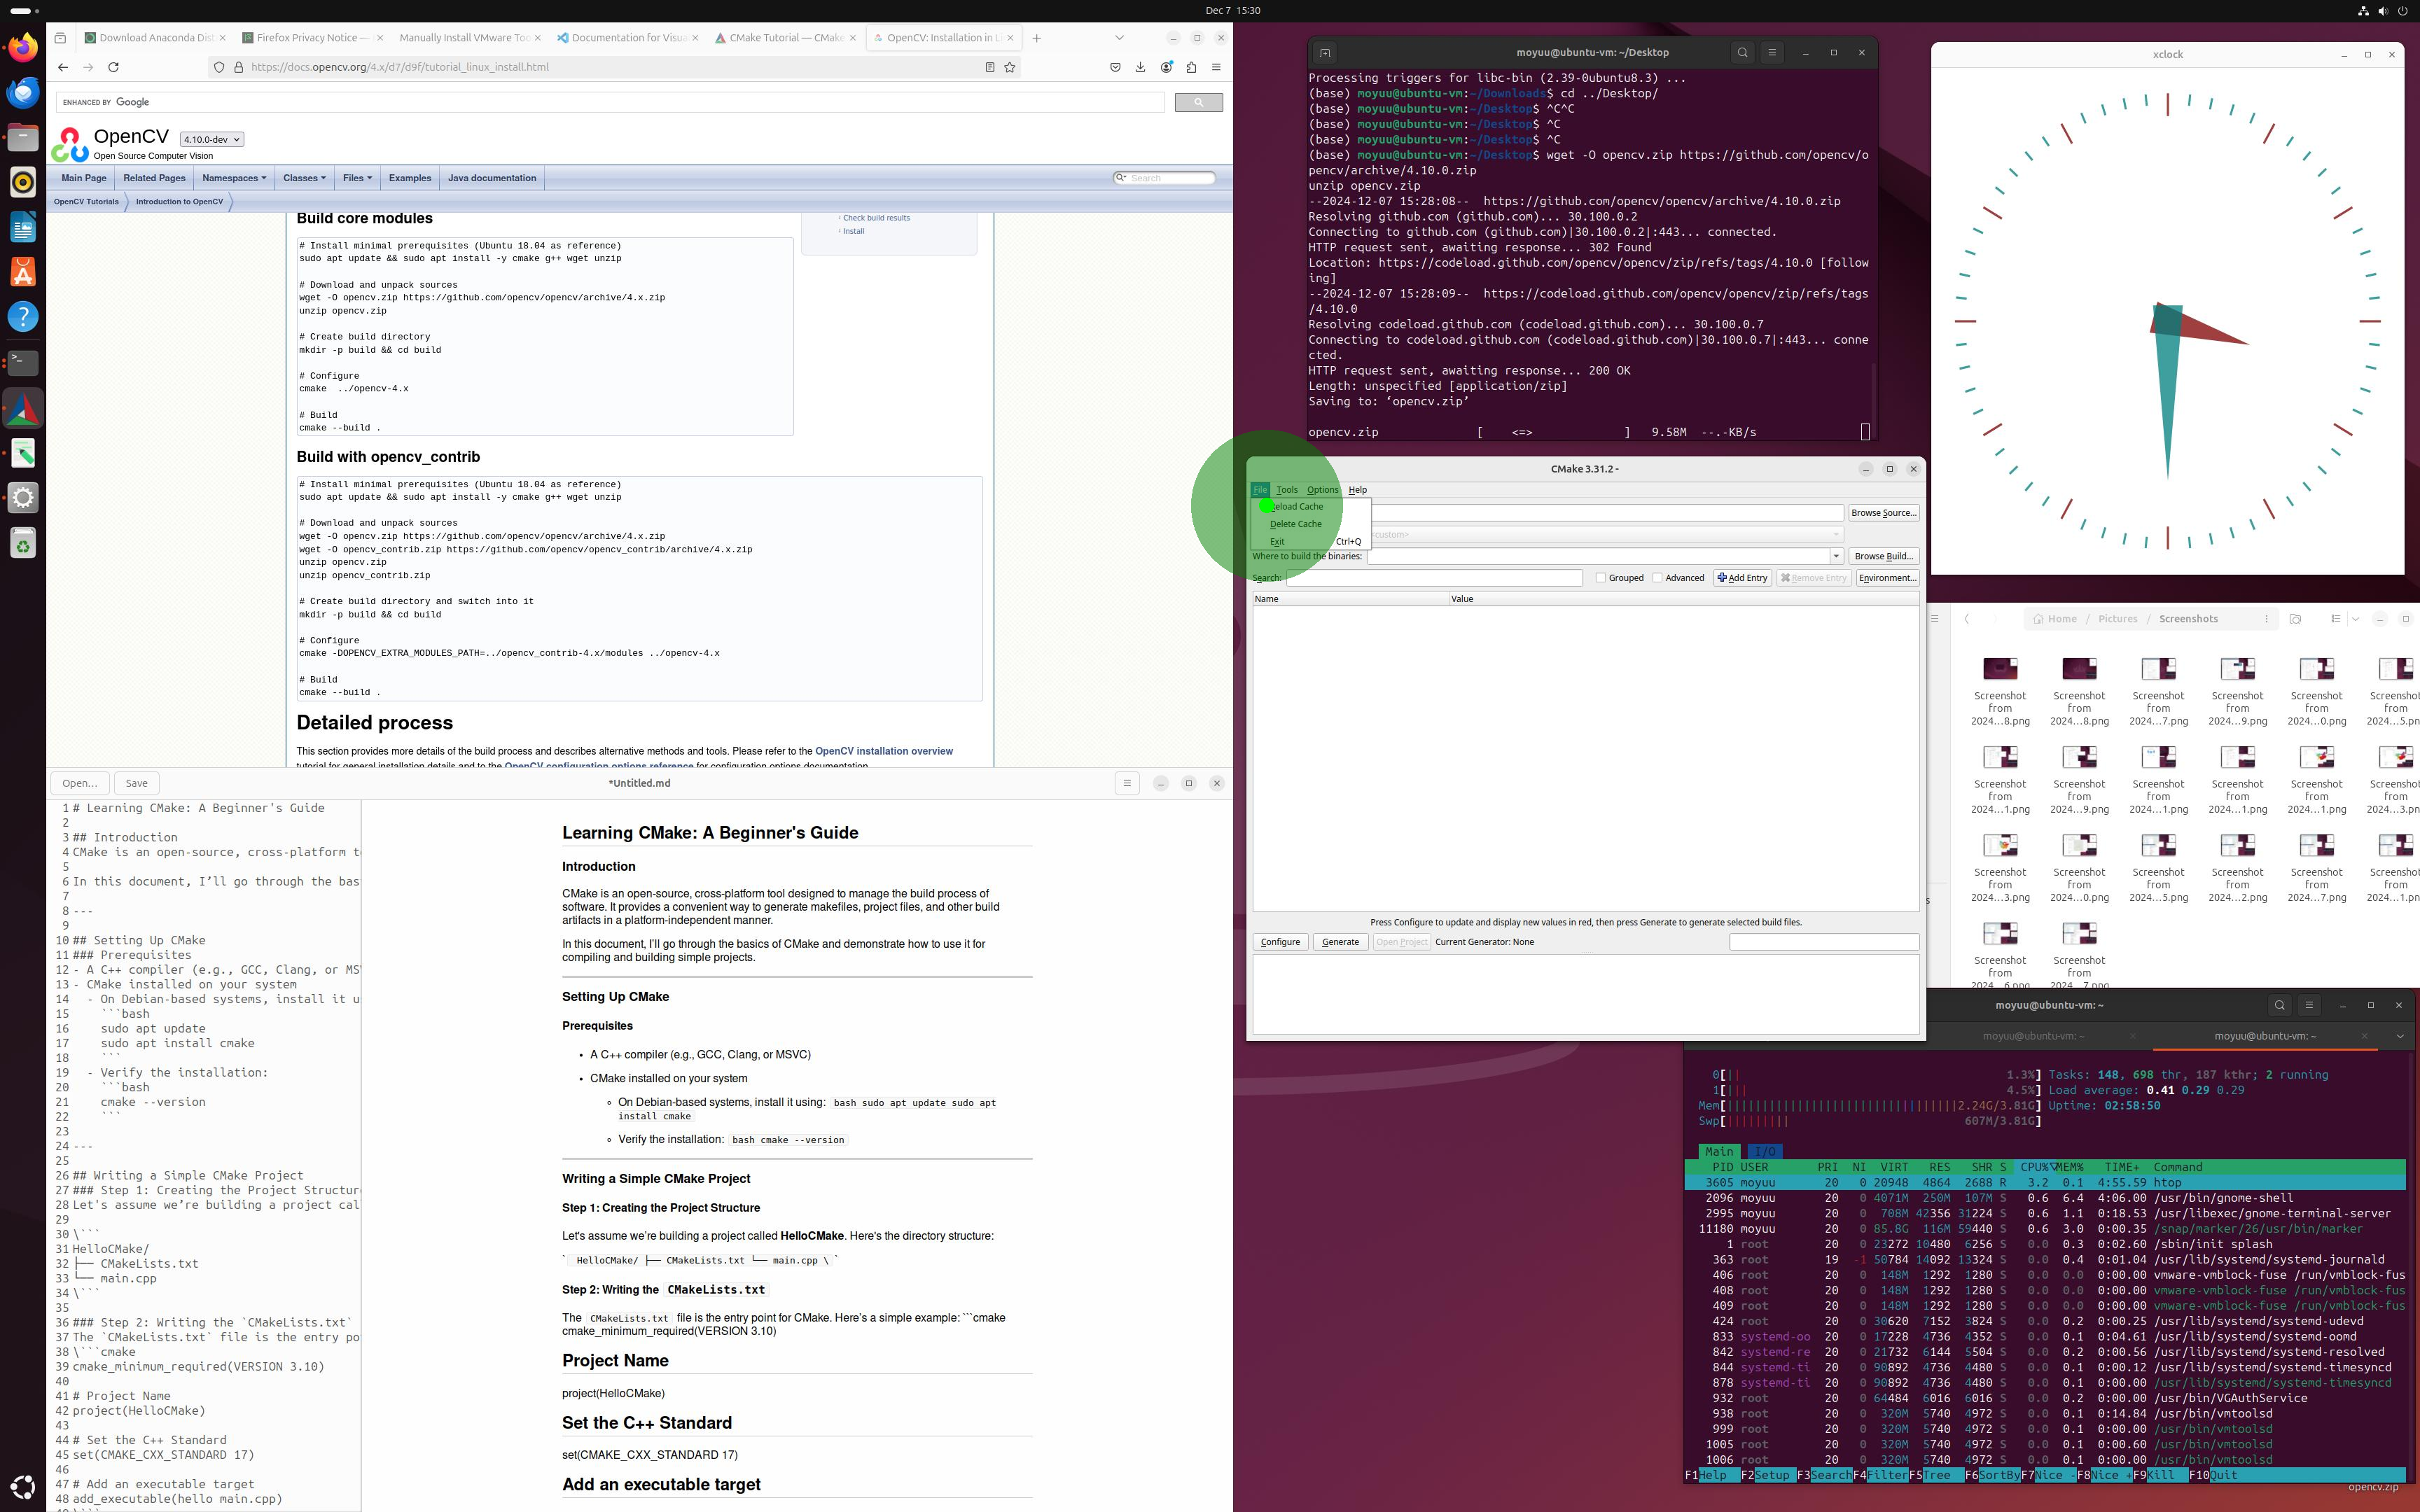

In [10]:
# Example usage
screenshot = "assets/computer_use/computer_use1.jpeg"
user_query = 'Reload cache'
output_text, display_image = perform_gui_grounding(screenshot, user_query, model, processor)

# Display results
print(output_text)
display(display_image)

<tool_call>
{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [1230, 769]}}
</tool_call>


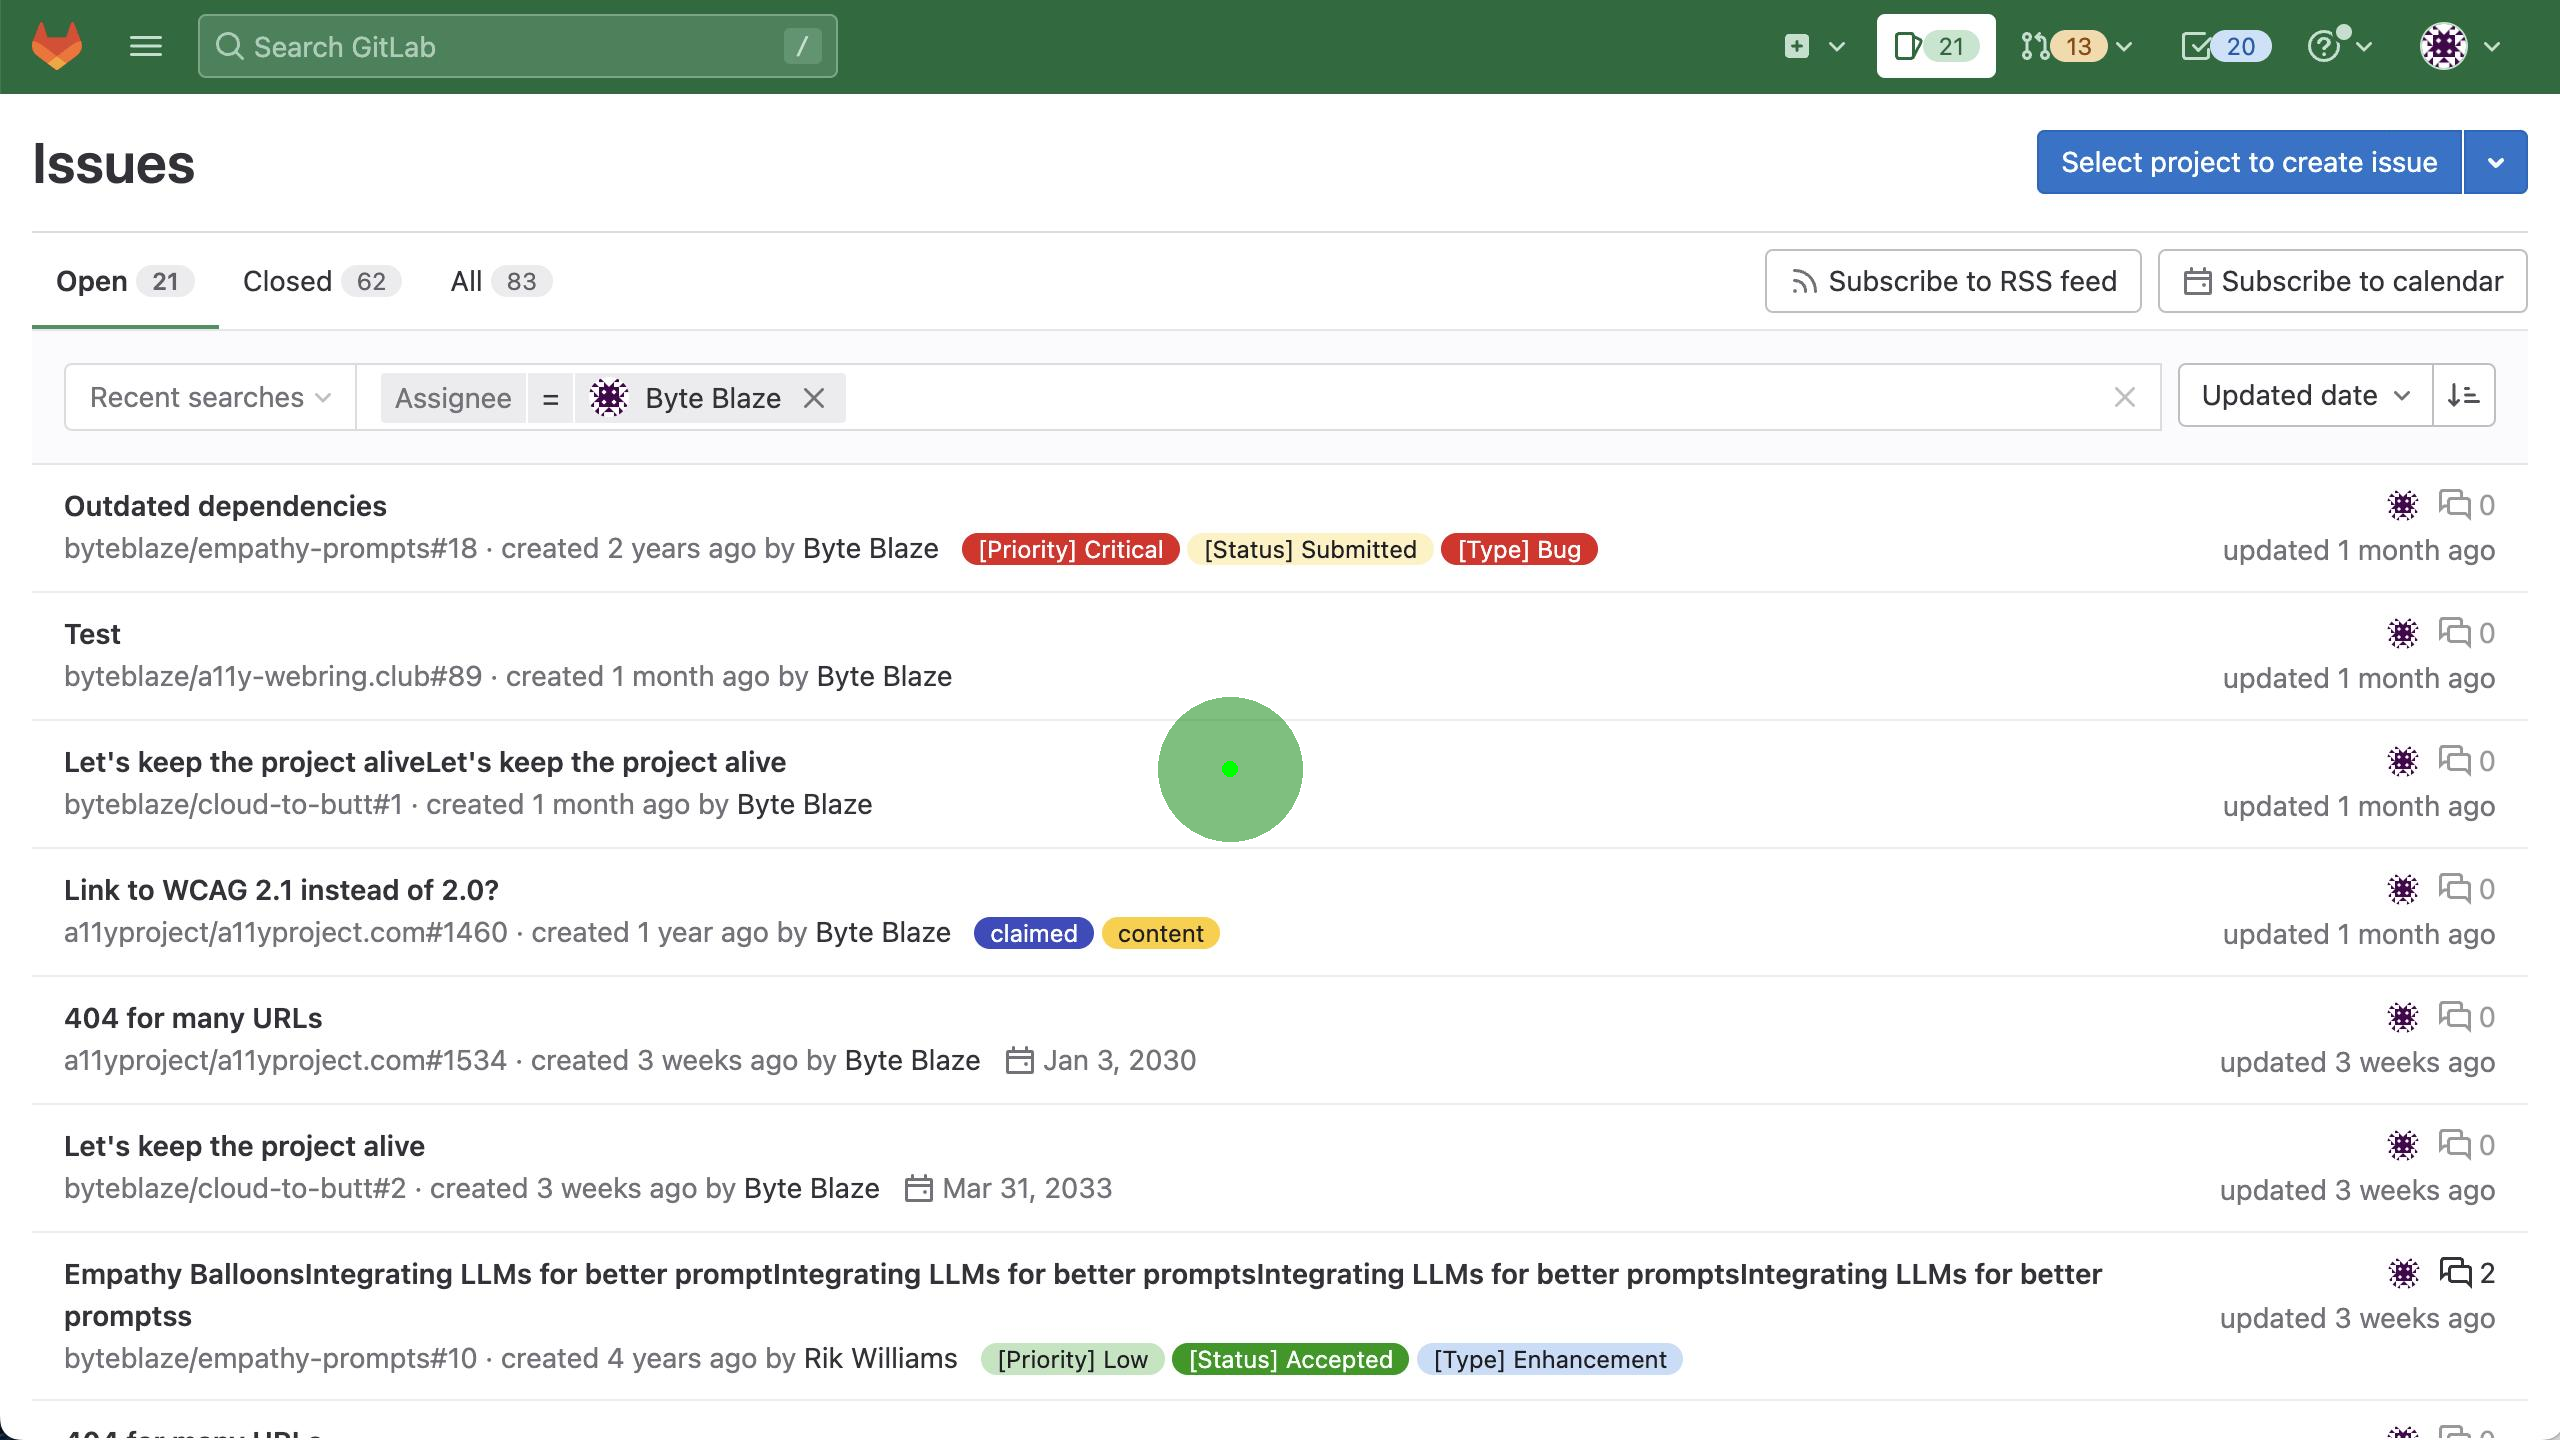

In [11]:
# Example usage
screenshot = "assets/computer_use/computer_use2.jpeg"
user_query = 'open the third issue'
output_text, display_image = perform_gui_grounding(screenshot, user_query, model, processor)

# Display results
print(output_text)
display(display_image)

<tool_call>
{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [563, 426]}}
</tool_call>


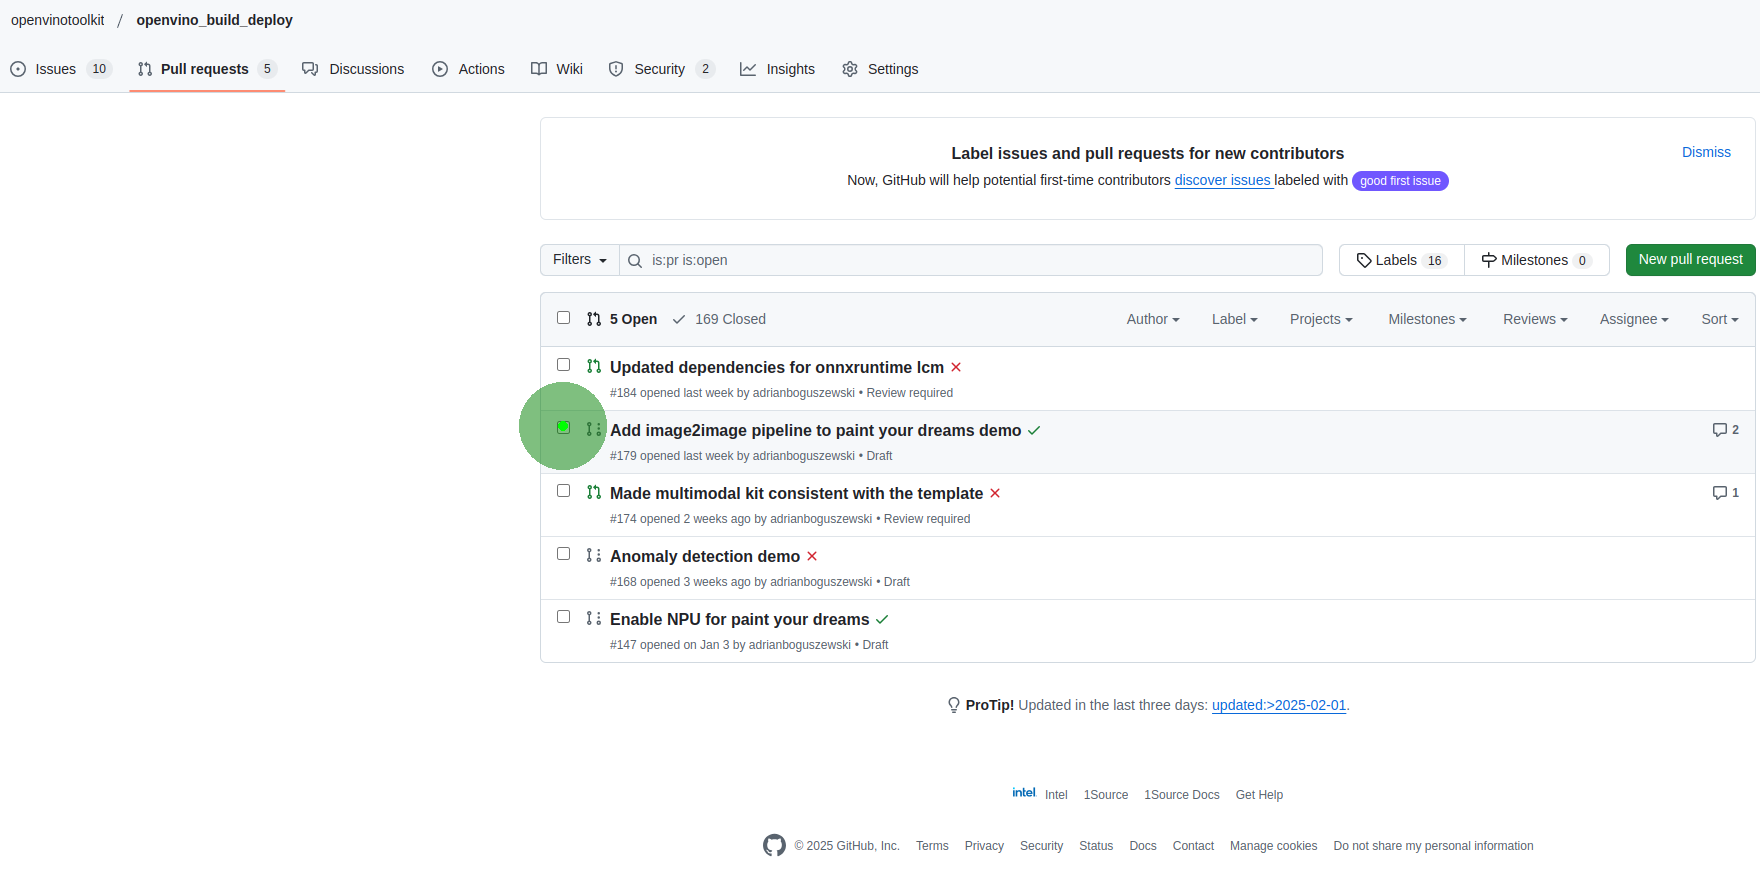

In [16]:
# Example usage
screenshot = "assets/computer_use/screenshot-PR.png"
user_query = 'select the Pull Request with more comments'
output_text, display_image = perform_gui_grounding(screenshot, user_query, model, processor)

# Display results
print(output_text)
display(display_image)